<a href="https://colab.research.google.com/github/Anhthu-2804/63135615_Web2/blob/main/notebooks/model_playground.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Environment

In [1]:
import os
import io
import time
import requests
import zipfile
import torch
import numpy as np
import matplotlib.pyplot as plt
import cv2
import torch
import numpy as np
import torchvision.transforms as transforms
from PIL import Image

In [2]:
# clone the git repository and set it as the working directory
! git clone https://github.com/martin-marek/parking-space-occupancy
os.chdir('parking-space-occupancy')

Cloning into 'parking-space-occupancy'...
remote: Enumerating objects: 86, done.
remote: Counting objects: 100% (26/26), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 86 (delta 18), reused 17 (delta 17), pack-reused 60 (from 1)
Receiving objects: 100% (86/86), 3.58 MiB | 15.02 MiB/s, done.
Resolving deltas: 100% (36/36), done.


In [3]:
# download the dataset
if not os.path.exists('dataset/data'):
    r = requests.get("https://pub-e8bbdcbe8f6243b2a9933704a9b1d8bc.r2.dev/parking%2Frois_gopro.zip")
    z = zipfile.ZipFile(io.BytesIO(r.content))
    z.extractall('dataset/data')

# Visualize dataset

In [4]:
from dataset import acpds
from utils import transforms
from utils import visualize as vis

In [5]:
train_ds, valid_ds, test_ds = acpds.create_datasets('dataset/data')

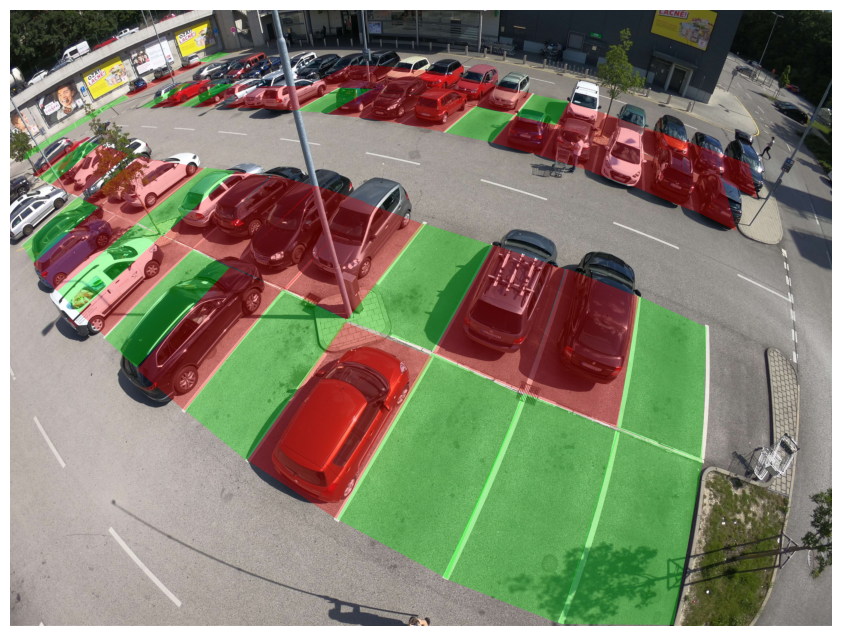

In [6]:
image_batch, rois_batch, labels_batch = next(iter(valid_ds))
image_raw, rois, labels = image_batch[0], rois_batch[0], labels_batch[0]
image = transforms.preprocess(image_raw, res=1440)
vis.plot_ds_image(image, rois, labels, show=True)

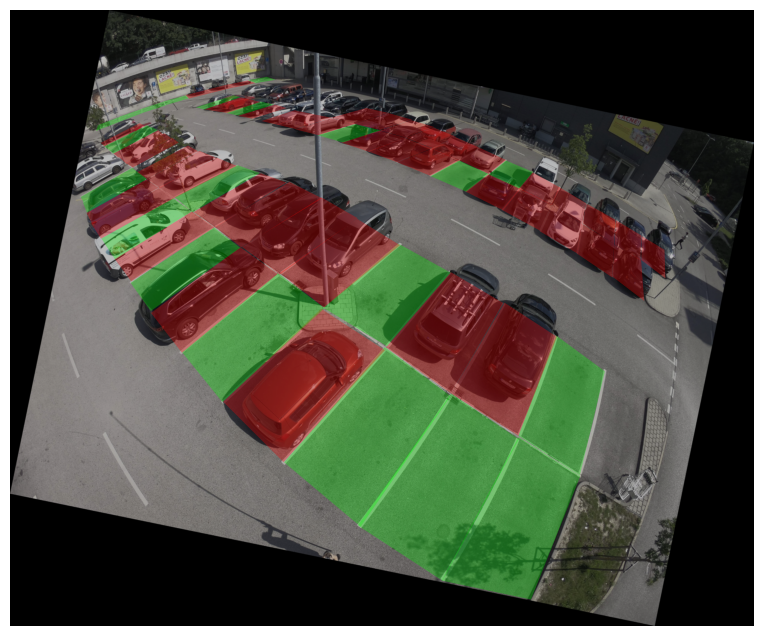

In [7]:
image_raw, rois, labels = image_batch[0], rois_batch[0], labels_batch[0]
image_aug, rois_aug = transforms.augment(image_raw, rois)
image_aug = transforms.preprocess(image_aug, res=1440)
vis.plot_ds_image(image_aug, rois_aug, labels, show=True)

# Plot model predictions

In [8]:
import matplotlib.pyplot as plt

In [9]:
from google.colab import files
uploaded = files.upload()


Saving video.mp4 to video.mp4


In [12]:
# Đọc video
video_path = 'video.mp4'
cap = cv2.VideoCapture(video_path)

In [13]:
import os

# Kiểm tra danh sách các tệp trong thư mục hiện tại
print(os.listdir())


['.gitignore', 'train_all_models.py', 'video.mp4', 'utils', 'README.md', 'illustrations', 'notebooks', 'pd_repo_test.ipynb', 'models', '.git', 'LICENSE', '.gitattributes', 'dataset']


In [14]:
from models.rcnn import RCNN

# Tạo mô hình
model = RCNN()

# Tải trọng số mô hình
weights_path = 'weights.pt'
if not os.path.exists(weights_path):
    # Không cần tải tệp video ở đây
    print("Không cần tải trọng số từ video, vì video không phải là trọng số mô hình.")
else:
    # Tải trọng số mô hình
    model.load_state_dict(torch.load(weights_path, map_location='cpu'))

Không cần tải trọng số từ video, vì video không phải là trọng số mô hình.


In [15]:
# Kiểm tra nếu video được mở thành công
if not cap.isOpened():
    print("Không thể mở video.")
    exit()


In [16]:
# Lấy thông tin về video (kích thước và số khung hình)
frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)

In [17]:
# Khởi tạo writer để lưu video kết quả
out_path = 'output_video.mp4'
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(out_path, fourcc, fps, (frame_width, frame_height))

In [22]:
import torchvision

In [24]:
import torchvision.transforms as transforms

# Kiểm tra xem hàm ToTensor() có tồn tại trong thư viện transforms hay không
if hasattr(transforms, "ToTensor"):
    print("Hàm ToTensor() tồn tại trong thư viện transforms.")
else:
    print("Hàm ToTensor() không tồn tại trong thư viện transforms.")

# Bạn cũng có thể in ra danh sách các hàm và lớp trong thư viện transforms
print(dir(transforms))

Hàm ToTensor() tồn tại trong thư viện transforms.
['AugMix', 'AutoAugment', 'AutoAugmentPolicy', 'CenterCrop', 'ColorJitter', 'Compose', 'ConvertImageDtype', 'ElasticTransform', 'FiveCrop', 'GaussianBlur', 'Grayscale', 'InterpolationMode', 'Lambda', 'LinearTransformation', 'Normalize', 'PILToTensor', 'Pad', 'RandAugment', 'RandomAdjustSharpness', 'RandomAffine', 'RandomApply', 'RandomAutocontrast', 'RandomChoice', 'RandomCrop', 'RandomEqualize', 'RandomErasing', 'RandomGrayscale', 'RandomHorizontalFlip', 'RandomInvert', 'RandomOrder', 'RandomPerspective', 'RandomPosterize', 'RandomResizedCrop', 'RandomRotation', 'RandomSolarize', 'RandomVerticalFlip', 'Resize', 'TenCrop', 'ToPILImage', 'ToTensor', 'TrivialAugmentWide', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '_functional_pil', '_functional_tensor', '_presets', 'autoaugment', 'functional', 'transforms']


In [25]:
while True:
    ret, frame = cap.read()
    if not ret:
        break  # Dừng nếu không còn khung hình nào


    # Tiền xử lý khung hình
    image = frame
    image_tensor = transforms.ToTensor()(image).unsqueeze(0)  # Chuyển đổi sang tensor và thêm chiều batch

    # Dự đoán với mô hình RCNN
    with torch.no_grad():
        class_logits = model(image_tensor)
        class_scores = class_logits.softmax(1)[:, 1]  # Xác suất cho lớp 'đã đỗ'

    # Vẽ các bounding box lên khung hình
    rois = class_scores > 0.5  # Lọc các ROIs có xác suất cao hơn 50% (đã đỗ)
    for i, roi in enumerate(rois):
        if roi:
            # Vẽ hộp bao quanh (bounding box) lên video
            x1, y1, x2, y2 = roi
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)  # Màu xanh cho xe đã đỗ

    # Lưu khung hình đã được vẽ bounding boxes
    out.write(frame)


TypeError: RCNN.forward() missing 1 required positional argument: 'rois'

In [11]:
# create model
from models.rcnn import RCNN
model = RCNN()

# load model weights
weights_path = 'weights.pt'
if not os.path.exists(weights_path):
    r = requests.get('video.mp4')
    with open(weights_path, 'wb') as f:
        f.write(r.content)
model.load_state_dict(torch.load(weights_path, map_location='cpu'))

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:03<00:00, 32.4MB/s]


MissingSchema: Invalid URL 'video.mp4': No scheme supplied. Perhaps you meant https://video.mp4?

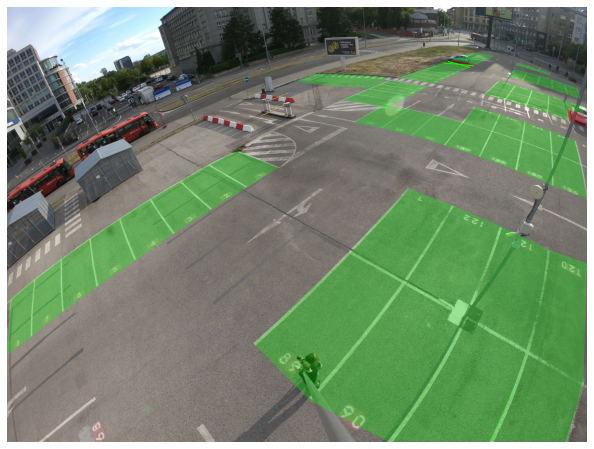

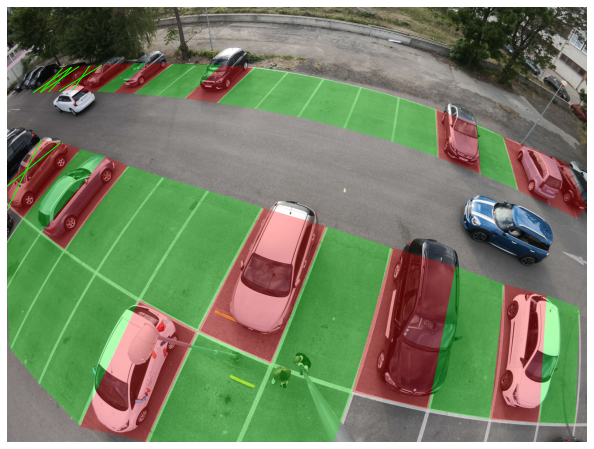

In [ ]:
# plot test predictions
for i, (image_batch, rois_batch, labels_batch) in enumerate(test_ds):
    if i == 2: break
    image, rois, labels = image_batch[0], rois_batch[0], labels_batch[0]
    image = transforms.preprocess(image)
    with torch.no_grad():
        class_logits = model(image, rois)
        class_scores = class_logits.softmax(1)[:, 1]
    vis.plot_ds_image(image, rois, class_scores, labels)

# Plot ROI warps

In [ ]:
from models.utils import pooling

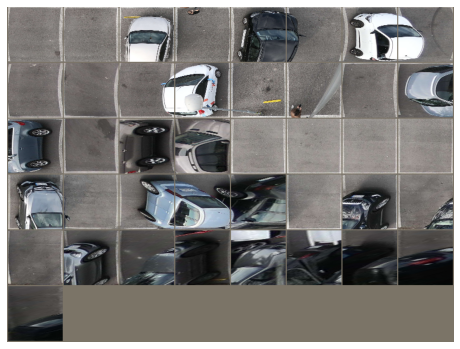

In [ ]:
warps = pooling.roi_pool(image, rois, 100, 'qdrl')
vis.show_warps(warps)

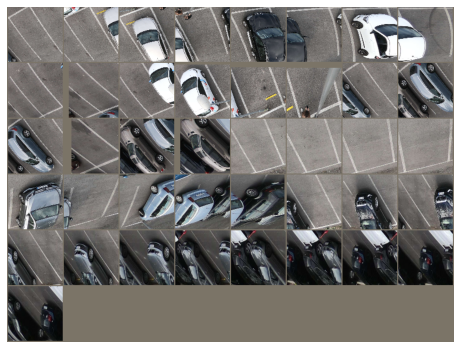

In [ ]:
warps = pooling.roi_pool(image, rois, 100, 'square')
vis.show_warps(warps)

# Speed comparison

In [ ]:
from models.rcnn import RCNN
from models.faster_rcnn_fpn import FasterRCNN_FPN

In [ ]:
def time_model(model, res=[1920, 1440], n=3):
    image = torch.zeros([3, res[1], res[0]])
    L_arr = torch.linspace(1, 100, steps=10, dtype=torch.int32)
    mean = np.zeros_like(L_arr, dtype=np.float32)
    ese = np.zeros_like(L_arr, dtype=np.float32)
    for i, L in enumerate(L_arr):
        times = np.zeros(n)
        for j in range(n):
            rois = torch.rand([L, 4, 2])
            t0 = time.time()
            out = model(image, rois)
            t1 = time.time()
            times[j] = t1 - t0
        mean[i] = np.mean(times)
        ese[i] = np.std(times) / np.sqrt(len(times))
    return L_arr, mean, ese

In [ ]:
times = {}
times['R-CNN (64)']  = time_model(RCNN(roi_res=64),  res=[4000, 3000])
times['R-CNN (128)'] = time_model(RCNN(roi_res=128), res=[4000, 3000])
times['R-CNN (256)'] = time_model(RCNN(roi_res=256), res=[4000, 3000])
times['Faster R-CNN FPN (800)']   = time_model(FasterRCNN_FPN(), res=[1067, 800])
times['Faster R-CNN FPN (1100)']  = time_model(FasterRCNN_FPN(), res=[1467, 1100])
times['Faster R-CNN FPN (1440)']  = time_model(FasterRCNN_FPN(), res=[1920, 1440])

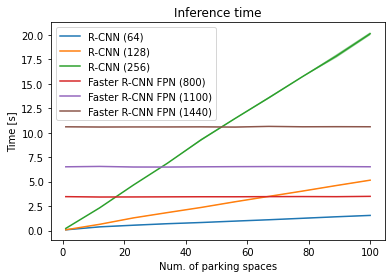

In [ ]:
for k, v in times.items():
    plt.plot(v[0], v[1], label=k)
    plt.fill_between(v[0], v[1]-v[2], v[1]+v[2], alpha=0.5)

plt.title('Inference time')
plt.xlabel('Num. of parking spaces')
plt.ylabel('Time [s]')
plt.legend()
plt.show()

# FPN level resolutions

In [ ]:
from torchvision.models.detection.backbone_utils import resnet_fpn_backbone
backbone = resnet_fpn_backbone('resnet50', pretrained=False)
image = torch.zeros([3, 1920, 1440])
out = backbone.body(image[None])
for k, v in out.items():
    print(k, v.shape)

0 torch.Size([1, 256, 480, 360])
1 torch.Size([1, 512, 240, 180])
2 torch.Size([1, 1024, 120, 90])
3 torch.Size([1, 2048, 60, 45])
